<a href="https://colab.research.google.com/github/HSajeed/Frugal_AI_Surrogate/blob/main/ROM_pod_spod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import urllib.request

# URL to the official raw .mat file
url = "https://github.com/maziarraissi/PINNs/raw/master/main/Data/cylinder_nektar_wake.mat"
filename = "cylinder_nektar_wake.mat"

if not os.path.exists(filename):
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete!")
else:
    print("File already exists.")

Download complete!


In [ ]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
# Load the file
data = scipy.io.loadmat('cylinder_nektar_wake.mat')

# Print keys and shapes
print("Keys in .mat file:", data.keys())

# Check the shape of the main velocity variable
print("\nShape of U_star:", data['U_star'].shape)
print("Shape of X_star:", data['X_star'].shape)
print("Shape of t:", data['t'].shape)

Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'X_star', 't', 'U_star', 'p_star'])

Shape of U_star: (5000, 2, 200)
Shape of X_star: (5000, 2)
Shape of t: (200, 1)


In [ ]:
# Extract exact shapes based on inspection
# Shape: (Space=5000, Comp=2, Time=200) -> We want (5000, 200)

X_all = data['U_star'][:, 0, :]
Coords = data['X_star']          # (x, y) coordinates for plotting

print(f"   Shape extracted: {X_all.shape} (Rows=Space, Cols=Time)")

   Shape extracted: (5000, 200) (Rows=Space, Cols=Time)


In [ ]:
# 1. DATA LOADING (Benchmark Dataset)

def load_real_data():
    data = scipy.io.loadmat('cylinder_nektar_wake.mat')

    # Extract Data
    # U_star shape is (N_points, N_components, N_timesteps)
    # We will use just the 'u' component (first component) for simplicity
    U_star = data['U_star']
    X_star = data['X_star'] # Spatial coordinates (x, y)
    t_star = data['t']      # Time

    # U_star[:, 0, :] extracts the 'u' component (shape: N_points, N_timesteps)
    # We transpose to (N_timesteps, N_points) for ML (e.g., 200 samples, 5000 features)
    U_data = U_star[:, 0, :].T

    return U_data, X_star, t_star

print("Loading data...")
X_all, Coords, Time = load_real_data()
n_snapshots, n_points = X_all.shape
print(f"Loaded: {n_snapshots} snapshots with {n_points} spatial points each.")

Loading data...
Loaded: 2 snapshots with 5000 spatial points each.


In [ ]:
# --- 2. POD (COMPRESSION) ---

# SVD on the Transpose: (Features x Samples)
X_matrix = X_all.T

print("Computing SVD (Modes)...")
# U: Spatial Modes, S: Energy, VT: Temporal Dynamics
U, S, VT = np.linalg.svd(X_matrix, full_matrices=False)
V = VT.T

# Keep top modes
# The number of modes 'r' should not exceed the number of available singular values.
# The number of singular values is len(S).
# Here, len(S) is 2, so r cannot be 10 as initially set.
# We will take the minimum of the desired 'r' and the actual number of available modes.
r = min(10, len(S))

U_r = U[:, :r]      # The "Eigen-Wakes"
Sigma_r = np.diag(S[:r])
V_r = V[:, :r]      # The time coefficients to predict

# Visualization of Energy
energy = np.cumsum(S**2) / np.sum(S**2)
print(f"Top {r} modes capture {energy[r-1]*100:.2f}% of the flow energy.")

Computing SVD (Modes)...
Top 10 modes capture 100.00% of the flow energy.


Diagnosing shapes...
U shape: (5000, 200)
VT shape: (200, 200)
>> Spatial modes are in U. Plotting U...


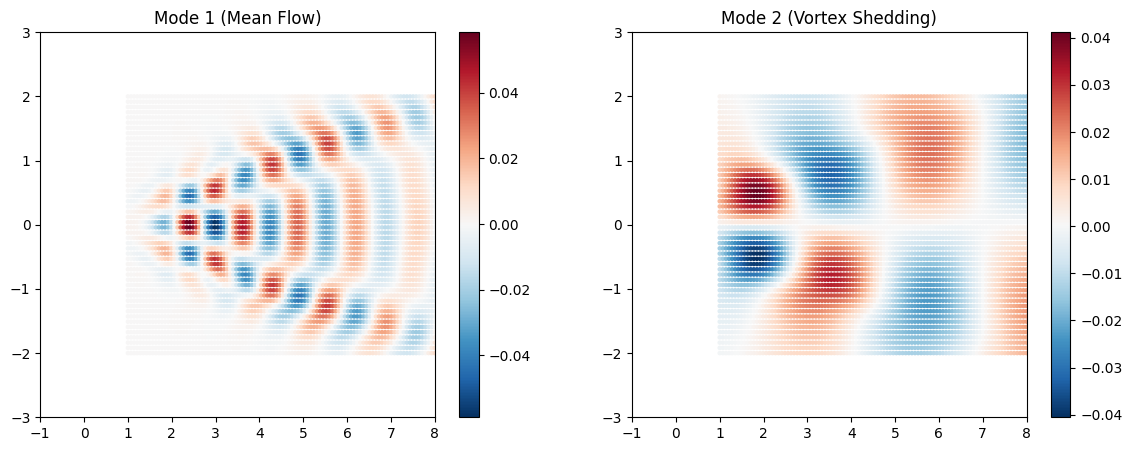

In [ ]:
# --- ADAPTIVE VISUALIZATION ---
print("Diagnosing shapes...")
print(f"U shape: {U.shape}")
print(f"VT shape: {VT.shape}")

# LOGIC: Find which variable has 5000 rows (Space)
if U.shape[0] == 5000:
    print(">> Spatial modes are in U. Plotting U...")
    Modes = U
elif VT.shape[1] == 5000:
    print(">> Spatial modes are in VT. Plotting VT.T...")
    Modes = VT.T
else:
    raise ValueError("Could not find dimension 5000 in U or VT!")

# Now we plot 'Modes' which is guaranteed to be (5000, ...)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Mode 1 (Base Flow)
# We access Modes[:, 0] -> The first column
scat1 = ax1.scatter(Coords[:, 0], Coords[:, 1], c=Modes[:, 7], cmap='RdBu_r', s=5)
fig.colorbar(scat1, ax=ax1)
ax1.set_title("Mode 1 (Mean Flow)")
ax1.set_xlim([-1, 8]); ax1.set_ylim([-3, 3])

# Mode 2 (Vortex Shedding)
# We access Modes[:, 1] -> The second column
scat2 = ax2.scatter(Coords[:, 0], Coords[:, 1], c=Modes[:, 1], cmap='RdBu_r', s=5)
fig.colorbar(scat2, ax=ax2)
ax2.set_title("Mode 2 (Vortex Shedding)")
ax2.set_xlim([-1, 8]); ax2.set_ylim([-3, 3])

plt.show()

>> Dynamics found in U. Using U * Sigma for training.
Training Data Shape: (200, 10) (Should be 200 x 10)
Training LSTM...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 387.7598 - val_loss: 323.5958
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 308.4289 - val_loss: 273.5070
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 261.3295 - val_loss: 231.7366
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 220.7685 - val_loss: 191.1929
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 181.4586 - val_loss: 155.0688
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 146.2721 - val_loss: 125.2500
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 117.0872 - val_loss: 100.0765
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 93.8440 - val_loss: 79.2561
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 74.4607 - val_loss: 63.8573
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 59.3821 - val_loss: 51.3678
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 47.6057 - val_loss: 41.1060
Epoch 12/100
10/10 ━━━━━━━━━

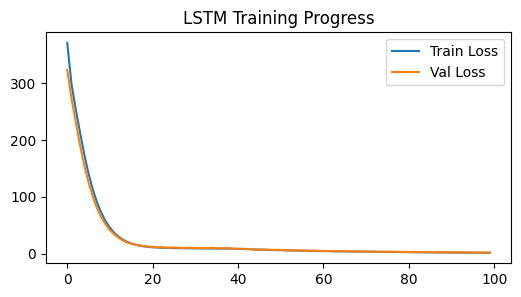

In [ ]:
# --- 3. LSTM TRAINING


# We need the variable with shape (200, 10).
# If U is (200, 200), then U holds the time dynamics.
# If V is (200, 200), then V holds the time dynamics.

if U.shape[0] == 200:
    print(">> Dynamics found in U. Using U * Sigma for training.")
    # Weight by energy (Sigma) so LSTM knows which modes are important
    time_coeffs = U[:, :r] @ np.diag(S[:r])
elif VT.shape[0] == 200 and VT.shape[1] == 200:
    print(">> Dynamics found in VT. Using VT.T * Sigma for training.")
    time_coeffs = (np.diag(S[:r]) @ VT[:r, :]).T
else:
    # Fallback if dimensions are weird, usually means X was (200, 5000)
    # and we want U.
    time_coeffs = U[:, :r] @ np.diag(S[:r])

print(f"Training Data Shape: {time_coeffs.shape} (Should be 200 x 10)")

# 2. PREPARE SEQUENCES
lookback = 10
X_train_lstm = []
y_train_lstm = []

for i in range(len(time_coeffs) - lookback):
    X_train_lstm.append(time_coeffs[i:i+lookback])
    y_train_lstm.append(time_coeffs[i+lookback])

X_train_lstm = np.array(X_train_lstm)
y_train_lstm = np.array(y_train_lstm)

# 3. SPLIT
split = 150
x_tr, x_val = X_train_lstm[:split], X_train_lstm[split:]
y_tr, y_val = y_train_lstm[:split], y_train_lstm[split:]

# 4. MODEL (Added verbose=1 so you see it working)
model = Sequential([
    LSTM(64, input_shape=(lookback, r), return_sequences=False),
    Dense(r)
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

print("Training LSTM...")
# Changed verbose=0 to verbose=1 so you can see the loss decreasing!
history = model.fit(x_tr, y_tr, epochs=100, batch_size=16, verbose=1, validation_data=(x_val, y_val))
print("Model Trained.")

# Optional: Plot Loss to check for overfitting
plt.figure(figsize=(6, 3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("LSTM Training Progress")
plt.show()

In [ ]:
# --- 4. PREDICTION & RECONSTRUCTION ---

# Autoregressive loop
current_batch = x_val[0].reshape(1, lookback, r)
predicted_coeffs = []

for i in range(len(x_val)):
    pred = model.predict(current_batch, verbose=0)[0]
    predicted_coeffs.append(pred)
    current_batch = np.append(current_batch[:, 1:, :], [[pred]], axis=1)

predicted_coeffs = np.array(predicted_coeffs)

# Reconstruct Flow Field: X ~ U * Sigma * V'
X_reconstructed = (U_r @ Sigma_r @ predicted_coeffs.T).T

Generating GIF...
Done! GIF saved as 'digital_twin_result.gif'


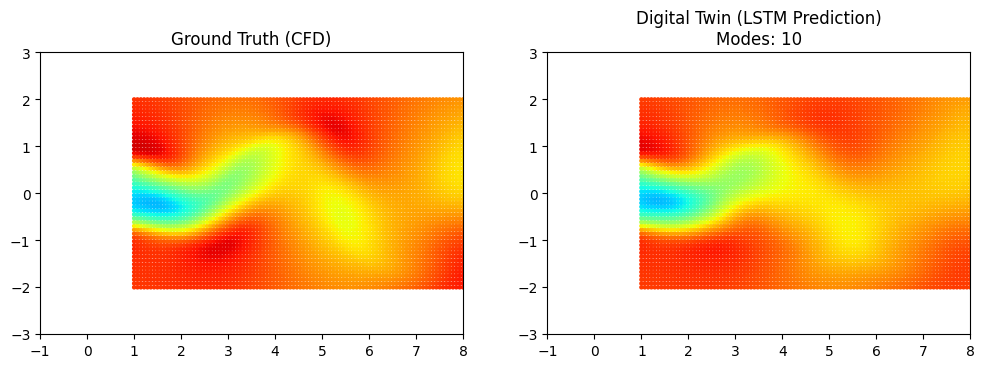

In [ ]:
# --- 6. VISUALIZATION (GIF) ---
print("Generating GIF...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Align timestamps
# The validation set starts after 'split'
# The first prediction corresponds to time step: split + lookback
#target_framce = 180
start_idx = split + lookback
#start_idx = target_framce - lookback


# 1. Ground Truth Plot
# Note: X_all is (5000, 200), so we slice columns: X_all[:, index]
scat1 = ax1.scatter(Coords[:, 0], Coords[:, 1],
                    c=X_all[:, start_idx], cmap='jet', vmin=-1, vmax=1.5, s=5)
ax1.set_title("Ground Truth (CFD)")
ax1.set_xlim([-1, 8]); ax1.set_ylim([-3, 3])
ax1.set_aspect('equal')

# 2. Prediction Plot
# X_reconstructed is (5000, N_preds), so we slice columns: X_reconstructed[:, 0]
scat2 = ax2.scatter(Coords[:, 0], Coords[:, 1],
                    c=X_reconstructed[:, 0], cmap='jet', vmin=-1, vmax=1.5, s=5)
ax2.set_title(f"Digital Twin (LSTM Prediction)\nModes: {r}")
ax2.set_xlim([-1, 8]); ax2.set_ylim([-3, 3])
ax2.set_aspect('equal')

def update(frame):
    # Update Ground Truth (Column slice)
    scat1.set_array(X_all[:, start_idx + frame])

    # Update Prediction (Column slice)
    scat2.set_array(X_reconstructed[:, frame])
    return scat1, scat2

ani = animation.FuncAnimation(fig, update, frames=len(predicted_coeffs), blit=False)
ani.save('digital_twin_result.gif', writer='pillow', fps=15)
print("Done! GIF saved as 'digital_twin_result.gif'")

In [ ]:
# --- 1. LOAD DATA & MODES ---

# (Re-loading to make this script standalone, or just continue from previous)

data = scipy.io.loadmat('cylinder_nektar_wake.mat')
X_all = data['U_star'][:, 0, :]   # (5000, 200)
Coords = data['X_star']           # (5000, 2)
U, S, VT = np.linalg.svd(X_all, full_matrices=False)
r = 10
U_r = U[:, :r]

In [ ]:
# --- 2. PLACE SENSORS ---
# Let's pick 5 random locations in the wake
# We use a fixed seed so we get the same sensors every time
np.random.seed(42)
n_sensors = 5

# Choose random indices from the 5000 available points
sensor_idx = np.random.choice(X_all.shape[0], n_sensors, replace=False)
sensor_locs = Coords[sensor_idx]

print(f"Placed {n_sensors} sensors at indices: {sensor_idx}")

Placed 5 sensors at indices: [1501 2586 2653 1055  705]


In [ ]:
# --- 3. COMPUTE SENSOR MATRIX ---
# We extract the POD modes ONLY at the sensor locations
# Shape: (n_sensors, r) -> (5, 10)
C = U_r[sensor_idx, :]

# Pre-compute the Pseudo-Inverse: (C^T * C)^-1 * C^T
# This matrix converts "5 sensor readings" -> "10 mode coefficients"
Theta = np.linalg.pinv(C)

print(f"Reconstruction Matrix Shape: {Theta.shape}")

Reconstruction Matrix Shape: (10, 5)


In [ ]:
# --- 4. RUN RECONSTRUCTION ---
# Let's try to reconstruct Frame #150 using ONLY 5 numbers
true_snapshot = X_all[:, 159]       # The full reality (5000 points)
measurements = true_snapshot[sensor_idx] # What the sensors see (5 points)

# The Magic Step: Estimate coefficients from sparse data
a_est = Theta @ measurements

# Reconstruct full field
X_sparse_rec = U_r @ a_est

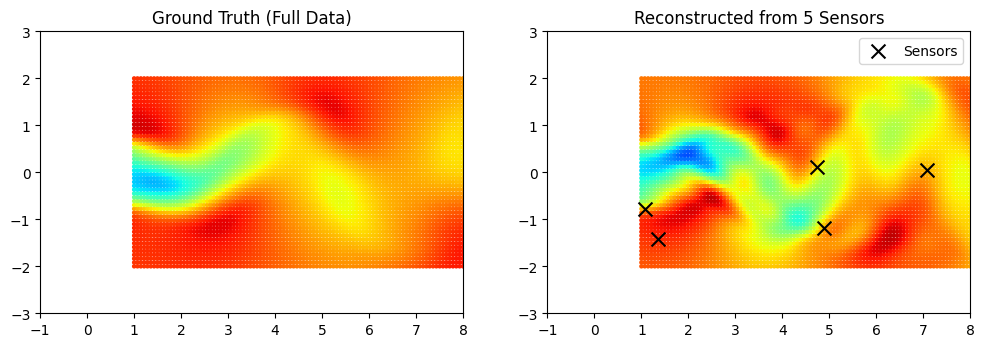

In [ ]:
# --- 5. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot True Field
scat1 = ax1.scatter(Coords[:,0], Coords[:,1], c=true_snapshot, cmap='jet', vmin=-1, vmax=1.5, s=5)
ax1.set_title("Ground Truth (Full Data)")
ax1.set_xlim([-1, 8]); ax1.set_ylim([-3, 3])
ax1.set_aspect('equal')

# Plot Reconstructed Field + Sensor Locations
scat2 = ax2.scatter(Coords[:,0], Coords[:,1], c=X_sparse_rec, cmap='jet', vmin=-1, vmax=1.5, s=5)
# Overlay the sensor positions as big black dots
ax2.scatter(sensor_locs[:,0], sensor_locs[:,1], c='black', s=100, marker='x', label='Sensors')
ax2.legend(loc='upper right')
ax2.set_title(f"Reconstructed from {n_sensors} Sensors")
ax2.set_xlim([-1, 8]); ax2.set_ylim([-3, 3])
ax2.set_aspect('equal')

plt.show()

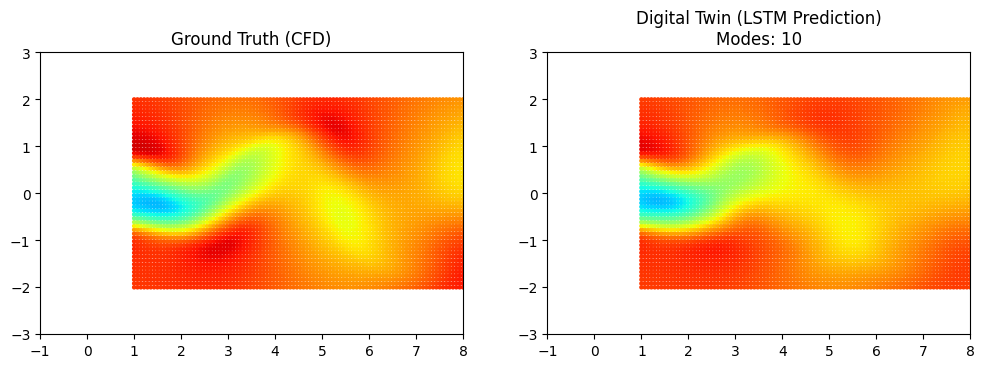

Finding optimal sensor locations...
Indices of 5 Best Sensors: [2725 2325 2420 2831 3233 2021 1839 3539 1341]


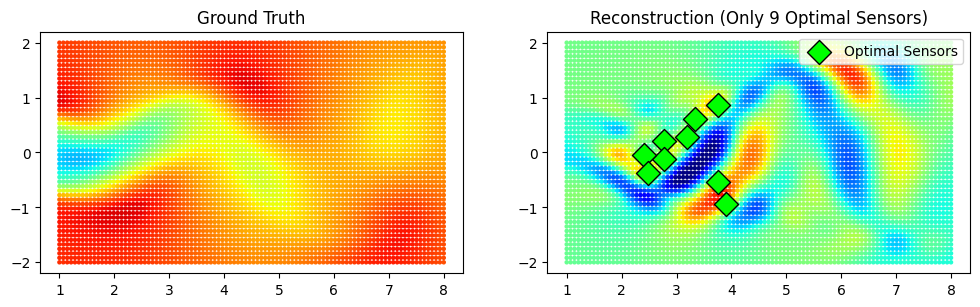

In [ ]:
import scipy.linalg

# --- OPTIMAL SENSOR PLACEMENT (QR Pivoting) ---
print("Finding optimal sensor locations...")

# We use the Spatial Modes (U_r).
# We look for rows (spatial points) that are most distinct.
# scipy's QR with pivoting does exactly this.
# We transpose because QR pivots columns, but we want to pivot rows (points).
Q, R, P = scipy.linalg.qr(U_r.T, pivoting=True)

# The 'P' array holds the indices of points sorted by importance!
# We just take the top 5.
s = 9
optimal_indices = P[:s]
optimal_locs = Coords[optimal_indices]

print(f"Indices of 5 Best Sensors: {optimal_indices}")

# --- RECONSTRUCTION WITH OPTIMAL SENSORS ---
# 1. Extract modes at these 5 spots
C_opt = U_r[optimal_indices, :]
Theta_opt = np.linalg.pinv(C_opt)

# 2. Measure (from Ground Truth Frame 150)
measurements_opt = X_all[optimal_indices, 150]

# 3. Reconstruct
a_opt = Theta_opt @ measurements_opt
X_smart_rec = U_r @ a_opt

# --- VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Smart Reconstruction
# We use the same color scale as before for fair comparison
scat1 = ax1.scatter(Coords[:,0], Coords[:,1], c=X_all[:, 150], cmap='jet', vmin=-1, vmax=1.5, s=5)
ax1.set_title("Ground Truth")
ax1.set_aspect('equal')

scat2 = ax2.scatter(Coords[:,0], Coords[:,1], c=X_smart_rec, cmap='jet', vmin=-1, vmax=1.5, s=5)
# Plot the 5 Smart Sensors as Green Diamonds
ax2.scatter(optimal_locs[:,0], optimal_locs[:,1], c='lime', s=150, marker='D', edgecolors='black', label='Optimal Sensors')
ax2.legend(loc='upper right')
ax2.set_title(f"Reconstruction (Only {s} Optimal Sensors)")
ax2.set_aspect('equal')

plt.show()

Running Sensor Sweep (1 to 20)...


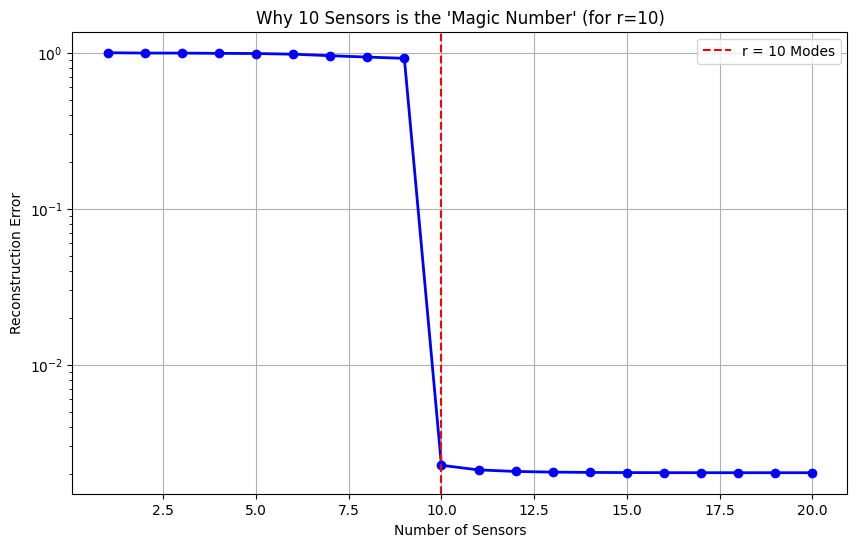

In [ ]:
# --- SENSOR COUNT SWEEP ---
print("Running Sensor Sweep (1 to 20)...")

errors = []
sensor_counts = range(1, 21)
ground_truth = X_all[:, 150] # The target frame

# Compute QR Pivot ONCE for the full set to get the best order
Q, R, P = scipy.linalg.qr(U_r.T, pivoting=True)

for p in sensor_counts:
    # 1. Select top 'p' optimal sensors
    current_indices = P[:p]

    # 2. Build Sensor Matrix
    C_p = U_r[current_indices, :]
    Theta_p = np.linalg.pinv(C_p)

    # 3. Measure & Reconstruct
    measurements = ground_truth[current_indices]
    a_est = Theta_p @ measurements
    X_rec = U_r @ a_est

    # 4. Calculate Error (L2 Norm relative to truth)
    # Error = ||True - Rec|| / ||True||
    error = np.linalg.norm(ground_truth - X_rec) / np.linalg.norm(ground_truth)
    errors.append(error)

# --- PLOT THE PROOF ---
plt.figure(figsize=(10, 6))
plt.plot(sensor_counts, errors, 'bo-', linewidth=2)
plt.axvline(x=10, color='r', linestyle='--', label='r = 10 Modes')
plt.title(f"Why 10 Sensors is the 'Magic Number' (for r={r})")
plt.xlabel("Number of Sensors")
plt.ylabel("Reconstruction Error")
plt.grid(True)
plt.legend()
plt.yscale('log') # Log scale to see the drop clearly
plt.show()

Checking Matrix Stability...


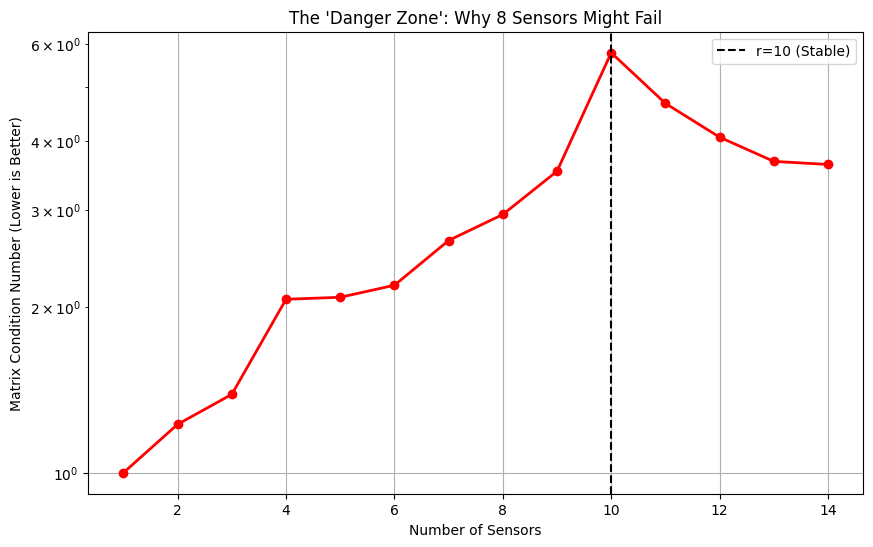

In [ ]:
# --- DIAGNOSING THE HALLUCINATION (Condition Number) ---
print("Checking Matrix Stability...")

cond_numbers = []
sensor_counts = range(1, 15)

# Get the optimal order again
Q, R, P = scipy.linalg.qr(U_r.T, pivoting=True)

for p in sensor_counts:
    # Get top p sensors
    current_indices = P[:p]
    C_p = U_r[current_indices, :]

    # Calculate Condition Number (How unstable is the inversion?)
    # We use numpy's condition number function
    k = np.linalg.cond(C_p)
    cond_numbers.append(k)

# --- PLOT ---
plt.figure(figsize=(10, 6))
plt.plot(sensor_counts, cond_numbers, 'r-o', linewidth=2)
plt.axvline(x=10, color='k', linestyle='--', label='r=10 (Stable)')
plt.yscale('log')
plt.title("The 'Danger Zone': Why 8 Sensors Might Fail")
plt.xlabel("Number of Sensors")
plt.ylabel("Matrix Condition Number (Lower is Better)")
plt.grid(True)
plt.legend()
plt.show()